# Machine Intelligence I
### Connectionist Neurons & Function Fitting
##### Group members: Abed Al Karim Taha, Rezwana Hussainzada, Salva Vali zadeh


#### Exercise H2.1: Connectionist Neurons
The dataset1 applesOranges.csv contains 200 measurements $(x_1\text{ and }x_2)$ from two types of objects as indicated by the column $y$. In this exercise, you will use a connectionist neuron with a “binary” transfer function $f(h)$ to classify the objects, i.e., obtain the predicted class $y$ for a data point $x \in R^2$ by

$$
y(x):=f(w^Tx-\theta)
$$
with
$$
f(h):=
\begin{cases}
1 \ \ \ \text{for } h>0\\
0 \ \ \ \text{for   otherwise}
\end{cases}
$$
##### (a)
where $h:=w^Tx-\theta$ is the total input to the neuron.
\subparagraph{(a}\label{a}
Plot the data in a scatter plot ($x_2$ vs. $x_1$). Mark the points with different colors to indicate the type of each object.
##### Answer:


The shape of data is : (200, 3)
Column names: ['x.1', 'x.2', 'y']


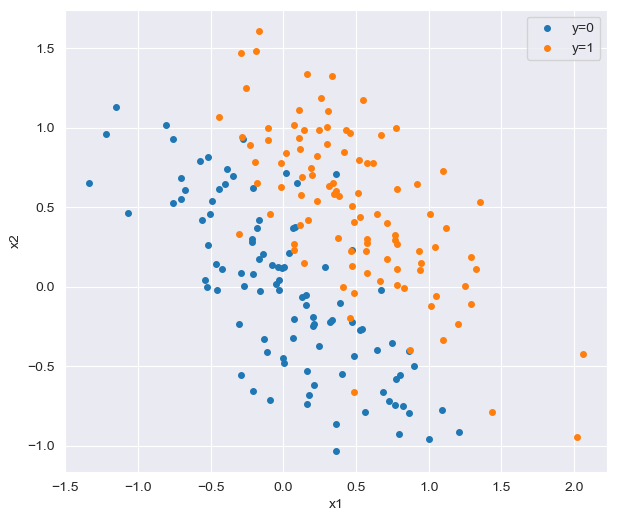

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
data = pd.read_csv("applesOranges.csv")

print(f"The shape of data is : {data.shape}")
print("Column names:", data.columns.tolist())

x1_zero = []
x1_one = []
x2_zero =[]
x2_one =[]

for n in range (len (data['y'])):
    if data['y'][n] == 0:
        x1_zero.append(data['x.1'][n])
        x2_zero.append(data['x.2'][n])
    else:
        x1_one.append(data['x.1'][n])
        x2_one.append(data['x.2'][n])


plt.figure(figsize=(7,6))
plt.scatter(x1_zero, x2_zero, s=16, label='y=0')
plt.scatter(x1_one, x2_one, s=16, label='y=1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

##### (b)
Set the bias $\theta = 0$. Create a set of 19 weight vectors $w = (w_1,w_2)^T$ pointing from the origin to the upper semicircle with radius 1 (i.e. if $y$ denotes the angle between the weight vector and the x-axis, for each $γ = 0, 10, . . . , 180$ (equally spaced) such that $||w||^2 = 1$, $w_1 \in [−1, 1],w_2 \in [0, 1]$).
For each of these weight vectors w,
##### (i)
determine % correct classifications $ρ$ of the corresponding neuron and
##### (ii)
Plot a curve showing $ρ$ as a function of $γ$.

##### Answer:

<class 'numpy.ndarray'>
(19, 2)
We build a matrix which its shape is (200, 19) and each column is predicted y for a weight vector.


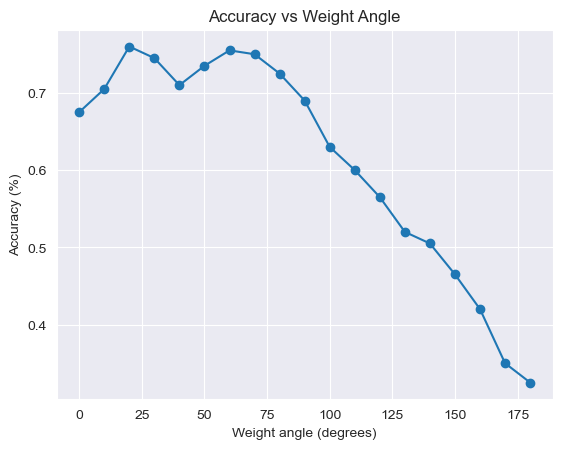

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Generate angles from 0° to 180° in steps of 10°
weight_angle_deg = np.arange(0, 181, 10)
weight_angle_rad = np.deg2rad(weight_angle_deg)  # Convert degrees to radians

# Generate 19 weight vectors on the upper semicircle (radius=1)
weights = np.vstack([np.cos(weight_angle_rad), np.sin(weight_angle_rad)]).T
print(type(weights))  # Check type of weights (should be ndarray)
print(weights.shape)
# Define step function neuron (threshold at 0)
def f(x):
    return 1 if x >= 0 else 0

# Prepare input data as a 2D array (rows: samples, columns: features)
data_np = np.array([data['x.1'], data['x.2']]).T

# Compute predicted outputs for each weight vector
# Each column corresponds to predictions of one weight vector
predicted_y = np.array([[f(weights[m] @ data_np[n]) for m in range(weights.shape[0])]for n in range(data.shape[0])])


print(f"We build a matrix which its shape is {predicted_y.shape} and each column is predicted y for a weight vector.")

# Compute classification accuracy for each weight vector
accuracy_matrix_0 = np.array([np.mean(predicted_y[:, t] == data['y']) for t in range(predicted_y.shape[1])])

# Plot accuracy vs weight angle
plt.plot(weight_angle_deg, accuracy_matrix_0, marker='o')
plt.xlabel("Weight angle (degrees)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Weight Angle")
plt.grid(True)
plt.show()

# Optional: print accuracies for each weight vector
for t in range(predicted_y.shape[1]):
    accuracy = np.mean(predicted_y[:, t] == data['y'])
    #print(f"Validation accuracy of weight vector {t+1}: {accuracy*100:.2f}%")


##### (c)
Out of the 19 weight vectors from above, pick the w that yields the best performance. Now, vary the bias $θ ∈ [−3, 3]$ and pick the value of θ that gives the best performance.
##### Answer:

Best weight vector for bias zero (θ=0) at angle 20°: [0.93969262 0.34202014].
with Accuracy: 76.00% when θ=0

Shape of 2D matrix: (200, 121) which its dimension 1 is the number of samples and its dimension 2 is the number of bias values.

Best accuracy with weight vector [0.93969262 0.34202014] and bias 0.150: 80.00%


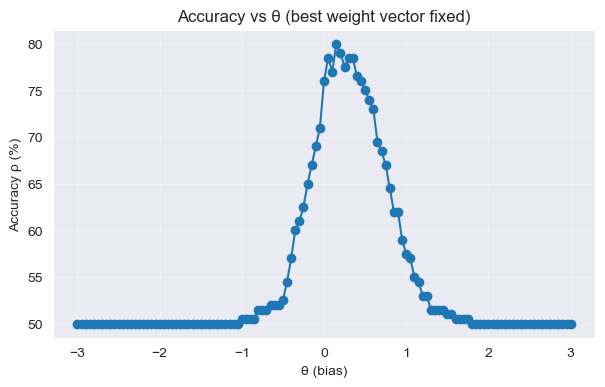

In [8]:
# accuracy array already computed for θ=0
best_idx = np.argmax(accuracy_matrix_0)
w_best = weights[best_idx]
print(f"Best weight vector for bias zero (θ=0) at angle {weight_angle_deg[best_idx]}°: {w_best}.")
print(f"with Accuracy: {accuracy_matrix_0[best_idx]*100:.2f}% when θ=0\n")

# θ ∈ [-3,3]

bias = np.linspace(-3, 3, 121)

#################################################
# Step 1

z = np.array([[
    f(w_best @ data_np[n] - bias[theta]) for theta in range(bias.shape[0])]
               for n in range(data_np.shape[0])])

print(f"Shape of 2D matrix: {z.shape} which its dimension 1 is the number of samples and its dimension 2 is the number of bias values.\n")

# Step 2
# Let's build an array from accuracy values for each bias value and weight vector.
accuracy_matrix_1 = np.array([np.mean(z[:,m] == data['y']) for m in range(bias.shape[0])])
#print(accuracy_matrix_1.shape)
# Now you can find the best bias from the accuracy matrix
best_idx = np.argmax(accuracy_matrix_1)
#print(best_idx)
theta_best = bias[best_idx]  # Extract bias value

print(f"Best accuracy with weight vector {w_best} and bias {theta_best:.3f}: {accuracy_matrix_1[best_idx] * 100:.2f}%")


# Step 4: Plot accuracy vs bias for best weight
plt.figure(figsize=(7,4))
plt.plot(bias, accuracy_matrix_1 * 100, marker='o')
plt.xlabel('θ (bias)')
plt.ylabel('Accuracy ρ (%)')
plt.title('Accuracy vs θ (best weight vector fixed)')
plt.grid(True, alpha=0.3)
plt.show()

##### (d)
Plot the data points and color them according to the predicted classification when using the $w$ and $θ$ that led to the highest performance. Plot the weight vector $w$ in the same plot. How do you interpret your results?

##### Answer:

w = [0.93969262 0.34202014]
theta = 0.15000000000000036


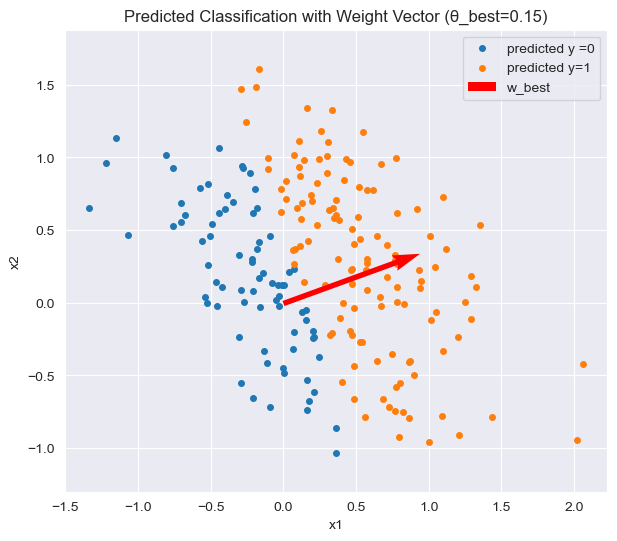

Interpretation: The arrow points in the direction where the neuron output increases. Because it points inputs which make the neuron fire.


In [9]:
# Remember w_best and theta_best were the best weight vector and bias term.
print(f"w = {w_best}")
print(f"theta = {theta_best}")

pr_y = np.array([[f(np.dot(w_best, data_np[n]) - theta_best)] for n in range(data_np.shape[0])])

x1_zero = []
x1_one = []
x2_zero =[]
x2_one =[]

for n in range(pr_y.shape[0]):
    if pr_y[n] == 0:
        x1_zero.append(data['x.1'][n])
        x2_zero.append(data['x.2'][n])
    else:
        x1_one.append(data['x.1'][n])
        x2_one.append(data['x.2'][n])

plt.figure(figsize=(7,6))
plt.scatter(x1_zero, x2_zero, s=16, label='predicted y =0')
plt.scatter(x1_one, x2_one, s=16, label='predicted y=1')
# Plot the weight vector
origin = [0], [0]  # origin point
plt.quiver(*origin, w_best[0], w_best[1], angles='xy', scale_units='xy', scale=1, color='r', label='w_best', width=0.01)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f"Predicted Classification with Weight Vector (θ_best={theta_best:.2f})")
plt.legend()
plt.grid(True)
plt.axis('equal')  # Equal aspect ratio
plt.show()

print("Interpretation: The arrow points in the direction where the neuron output increases. Because it points inputs which make the neuron fire.")


##### (e)
Find the best combination of $w$ and $θ$ by exploring all combinations of $γ$ and $θ$ (within a reasonable range and precision). Compute and plot the performance of all combinations in a heatmap.
##### Answer:

Best weight angle γ: 40°
Best bias θ: 0.30
Best accuracy: 90.00%


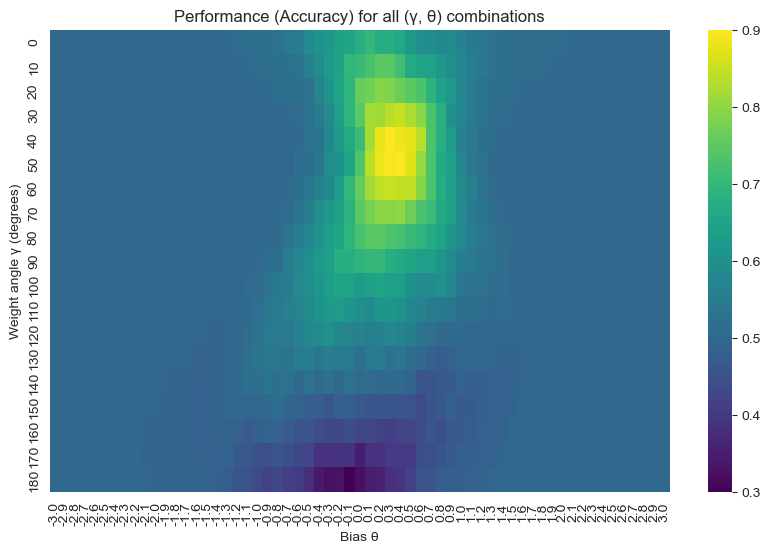

Brighter (or lighter) color = higher accuracy. Darker color = lower accuracy.


In [10]:
import numpy as np

# Weight angles in degrees and radians
gamma_deg = np.arange(0, 181, 10)  # step 10° for finer search
gamma_rad = np.deg2rad(gamma_deg)

# Bias values
theta_values = np.linspace(-3, 3, 61)  # 61 values from -3 to 3

weights = np.vstack([np.cos(gamma_rad), np.sin(gamma_rad)]).T
# shape = (num_angles, 2)

# Define step function neuron (threshold at 0)
def f(x):
    return 1 if x >= 0 else 0

n_gamma = weights.shape[0]
n_theta = len(theta_values)
n_samples = data_np.shape[0]


M = np.array([[[f(np.dot(weights[m], data_np[n]) - theta_values[theta])
               for n in range(n_samples)]
               for m in range(n_gamma)]
               for theta in range(n_theta)])


accuracy_matrix_2 = np.array([[
    np.mean(M[n,m,:] == data['y']) for n in range(n_theta)]
    for m  in range(n_gamma)])



best_idx = np.unravel_index(np.argmax(accuracy_matrix_2), accuracy_matrix_2.shape)
best_gamma_deg = gamma_deg[best_idx[0]]
best_theta = theta_values[best_idx[1]]
best_accuracy = accuracy_matrix_2[best_idx]

print(f"Best weight angle γ: {best_gamma_deg}°")
print(f"Best bias θ: {best_theta:.2f}")
print(f"Best accuracy: {best_accuracy*100:.2f}%")


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(accuracy_matrix_2, xticklabels=np.round(theta_values,2), yticklabels=gamma_deg, cmap='viridis')
plt.xlabel('Bias θ')
plt.ylabel('Weight angle γ (degrees)')
plt.title('Performance (Accuracy) for all (γ, θ) combinations')
plt.show()
print("Brighter (or lighter) color = higher accuracy. Darker color = lower accuracy.")

##### (f)
Can the grid-search optimization procedure used in (e) be applied to any classification problem? Discuss potential problems and give an application example in which the above
method must fail.
##### Answer:
No. Grid search only tests discrete combinations of $w$ and $\theta$ of a single neuron.
$$
y(x):=f(w^Tx-\theta)
$$
$$
f(h):=
\begin{cases}
1 \ \ \ \text{for } h>0\\
0 \ \ \ \text{for   otherwise}
\end{cases}
$$
This neuron defines a linear decision boundary $w^Tx-\theta = 0$. Therefore, it can separate data only when the classes are linearly separable. For nonlinear separable data, no choice of $w$ and $\theta$ can achieve perfect classification, so grid search must fail.

#### Exercise H2.2: Binary Classification
For binary targets $y_{T}^{(α)} ∈ \{0, 1\}$ the network output $y(x;w) ∈ (0, 1)$ can be interpreted as a probability $P(y = 1|x;w)$. A suitable error function for this problem is:

$$
E^T = \frac{1}{p}\Sigma_{\alpha =1}^{p} e^{(α)}
$$

with
$$
e^{(α)} = −[y^{(α)}_T \ln y(x^{(α)};w) + (1 − y^{(α)}_T) \ln (1 − y(x^{(α)};w))]
$$

##### (a)
Show that
$$
\frac{\partial e^{(α)}}{\partial y(x^{(α)};w)} =\frac{y(x^{(α)};w)-y^{(α)}_T}{y(x^{(α)};w)(1-y(x^{(α)};w))}
$$
##### Answer:
Let $y = y(x^{(α)};w)$ and $y_T = y_T^{(α)}$ for convenient .
$$
e = −[y_T \ln y + (1 − y_T) \ln (1 − y)] \\
\frac{\partial e}{\partial y} = -[y_T\frac{\partial (\ln y)}{\partial y}+(1 − y_T)\frac{\partial (\ln (1-y))}{\partial y}]
$$
We know:
$$
\frac{d}{dy}\ln y=\frac{1}{y}, \ \frac{d}{dy}\ln (1-y)=-\frac{1}{1-y}
$$

So :

$$
\frac{\partial e}{\partial y} = -[y_T\frac{1}{y}+(1 − y_T)(\frac{-1}{ 1-y})]\\
\frac{\partial e}{\partial y} = \frac{-(y_T(1-y))+y(1-y_T)}{y(1-y)}
$$
As:
$$
-(y_T(1-y))+y(1-y_T)=-y_T+y_Ty+y-yy_T=y-y_T
$$
We have :
$$
\frac{\partial e}{\partial y} = \frac{y-y_T}{y(1-y)}
$$
Remember we had $y = y(x^{(α)};w)$ and $y_T = y^{(α)}_T$:

$$
\frac{\partial}{\partial y(x^{(α)};w)}e^{(α)} =\frac{y(x^{(α)};w)-y^{(α)}_T}{y(x^{(α)};w)(1-y(x^{(α)};w))}
$$


##### (b)
Consider an MLP with one hidden layer. The nonlinear transfer function for the output neuron $(i = 1, v = 2)$ is assumed to be
$$
f(h_1^2) = \frac{1}{1+\exp(-h_1^2)}
$$
where $h_1^2$ is the total input of the output neuron. Show that its derivative can be expressed as

$$
f′(h^2_1) = f(h^2_1)(1 − f(h^2_1))
$$
##### Answer:
\begin{align}
f'(h^2_1) &= \frac{d}{d h^2_1}(1+\exp(-h_1^2))^{-1}\\
&=(-1)(1+\exp(-h_1^2))^{-2}\frac{d}{d h^2_1}(1+\exp(-h_1^2))\\
&=\frac{\exp(-h_1^2)}{(1+\exp(-h_1^2))^{-2}}
\end{align}
On the other hand we have:
\begin{align}
1-f(h_1^2) &= 1-\frac{1}{1+\exp(-h_1^2)}\\
&=\frac{\exp(-h_1^2)}{1+\exp(-h_1^2)}\\
f(h_1^2)(1-f(h_1^2)) &= \frac{1}{1+\exp(-h_1^2)}\frac{\exp(-h_1^2)}{1+\exp(-h_1^2)}\\
&=\frac{\exp(-h_1^2)}{(1+\exp(-h_1^2))^{-2}}
\end{align}
So:

$$f′(h^2_1) = f(h^2_1)(1 − f(h^2_1))$$

##### (c)
Using the results from (a) and (b), show that the gradient of the error function $e^{(α)}$ with respect to the weight $w^{21}_{1j}$ between the the single output neuron $(i = 1, v = 2)$ and neuron $j$ of the hidden layer $(j > 0, v = 1)$ is

$$
\frac{∂e^{(α)}}{∂w^{21}_{1j}}=
y(x^{(α)};w) − y^{(α)}_T)f(h^1_j).
$$

##### Answer:
We want to compute $\frac{\partial e^{(\alpha)}}{\partial w^{21}_{1j}}$. Let's use the chain rule:
$$
\frac{\partial e^{(\alpha)}}{\partial w^{21}_{1j}}
= \frac{\partial e^{(\alpha)}}{\partial h_1^2} \cdot \frac{\partial h_1^2}{\partial w^{21}_{1j}}
$$
where $h_1^2$ is the total input to the output neuron:
$$
h_1^2 = \sum_j w^{21}_{1j} f(h_j^1) + b
$$
In the next step we compute derivative of $h_1^2$ with respect to the weight:
$$
\frac{\partial h_1^2}{\partial w^{21}_{1j}} = f(h_j^1)
$$
From part (a) we have:
$$
\frac{\partial e}{\partial y} = \frac{y-y_T}{y(1-y)}
$$
Where $y = y(x^{(α)};w)=f'(h_1^2)$ and from part (b) we have :
$$
\frac{\partial y}{\partial h_1^2} = f'(h_1^2) = y(1-y)
$$

So if we use chain rule we have:
$$
\frac{\partial e^{(\alpha)}}{\partial h_1^2} = \frac{\partial e^{(\alpha)}}{\partial y} \cdot \frac{\partial y}{\partial h_1^2}
= \frac{y - y_T}{y(1-y)} \cdot y(1-y) = y - y_T
$$
Therefore:
\begin{align}
\frac{\partial e^{(\alpha)}}{\partial w^{21}_{1j}} &= \frac{\partial e^{(\alpha)}}{\partial h_1^2} \cdot \frac{\partial h_1^2}{\partial w^{21}_{1j}}
= (y - y_T) \cdot f(h_j^1)\\
& = (y(x^{(α)};w)-y_T^{(α)})f(h_j^1)
\end{align}